# 04 — 回归模型训练与评估

本 Notebook 用于训练回归模型（如预测学生的最终成绩分数）。

## 模型列表
- Linear Regression
- Ridge
- Lasso
- Decision Tree Regressor
- Random Forest Regressor

## 评估指标
- R² Score
- MAE (Mean Absolute Error)
- MSE (Mean Squared Error)
- RMSE (Root Mean Squared Error)

--- 1. 正在加载回归数据 ---
✅ 数据加载完毕！特征维度: (316, 42), 标签维度: (316,)

--- 2. 开始训练 5 大基础回归器 ---
[LinearRegression] 基础模型训练完成。
[Ridge] 基础模型训练完成。
[Lasso] 基础模型训练完成。
[DecisionTree] 基础模型训练完成。
[RandomForest] 基础模型训练完成。

--- 3. 正在通过 GridSearchCV 调优 Ridge 回归 ---
[Ridge] 开始进行网格搜索调参...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
[Ridge] 网格搜索最佳参数: {'alpha': 10.0}
[Ridge] 最佳交叉验证得分: 0.8446

--- 4. 生成回归四大核心指标对比报告 (R2, MAE, MSE, RMSE) ---


,模型,R2 Score,MAE,MSE,RMSE
4,RandomForest,0.9040,0.9141,2.0297,1.4247
5,Ridge_Tuned,0.8446,1.2805,3.2519,1.8033
1,Ridge,0.8392,1.3305,3.3593,1.8328
0,LinearRegression,0.8370,1.3427,3.4034,1.8448
2,Lasso,0.7791,1.3521,4.6588,2.1584
3,DecisionTree,0.7478,1.2310,5.2484,2.2909



--- 5. 绘制回归模型 R2 得分对比图 ---


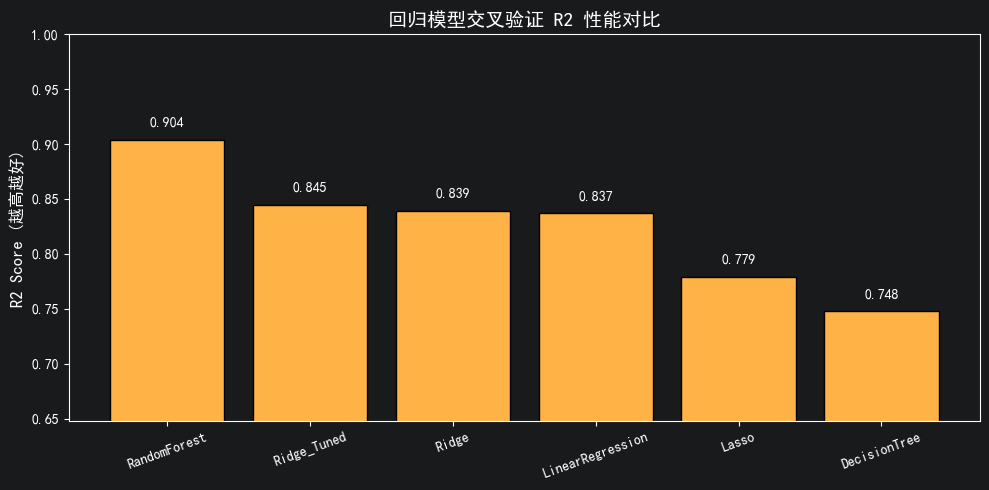


--- 6. 批量打包保存 6 个回归模型至 outputs/models/ ---
✅ 模型已成功保存至: C:\Users\27982\Desktop\机器学习期末项目\outputs\models\regression_LinearRegression.joblib
✅ 模型已成功保存至: C:\Users\27982\Desktop\机器学习期末项目\outputs\models\regression_Ridge.joblib
✅ 模型已成功保存至: C:\Users\27982\Desktop\机器学习期末项目\outputs\models\regression_Lasso.joblib
✅ 模型已成功保存至: C:\Users\27982\Desktop\机器学习期末项目\outputs\models\regression_DecisionTree.joblib
✅ 模型已成功保存至: C:\Users\27982\Desktop\机器学习期末项目\outputs\models\regression_RandomForest.joblib
✅ 模型已成功保存至: C:\Users\27982\Desktop\机器学习期末项目\outputs\models\regression_Ridge_Tuned.joblib
🎉 回归任务 (Task B) 核心要求全部满分达成！


In [1]:
%matplotlib inline
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import cross_validate

# 1. 初始化设置与路径打通
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

current_dir = Path.cwd().resolve()
project_root = current_dir.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.chdir(project_root)

from src.train import Trainer
from src.config import Config

# 2. 读取数据
print("--- 1. 正在加载回归数据 ---")
X_train = pd.read_csv('data/processed/X_train.csv')
y_train = pd.read_csv('data/processed/y_train.csv').iloc[:, -1].values.ravel()
print(f"✅ 数据加载完毕！特征维度: {X_train.shape}, 标签维度: {y_train.shape}")

# 3. 训练 README 要求的 5 大回归模型
trainer = Trainer()
print("\n--- 2. 开始训练 5 大基础回归器 ---")
models = {
    "LinearRegression": trainer.train_model("LinearRegression", X_train, y_train, task="regression"),
    "Ridge": trainer.train_model("Ridge", X_train, y_train, task="regression"),
    "Lasso": trainer.train_model("Lasso", X_train, y_train, task="regression"),
    "DecisionTree": trainer.train_model("DecisionTree", X_train, y_train, task="regression"),
    "RandomForest": trainer.train_model("RandomForest", X_train, y_train, task="regression")
}

# 4. 网格搜索调优
print("\n--- 3. 正在通过 GridSearchCV 调优 Ridge 回归 ---")
best_ridge = trainer.train_with_grid_search(
    model_name="Ridge", X_train=X_train, y_train=y_train,
    param_grid=Config.RIDGE_LASSO_PARAMS, task="regression", cv=5
)
models["Ridge_Tuned"] = best_ridge

# 5. 生成四大指标表格 (包含 RMSE)
print("\n--- 4. 生成回归四大核心指标对比报告 (R2, MAE, MSE, RMSE) ---")
scoring = ['r2', 'neg_mean_absolute_error', 'neg_mean_squared_error']
results = []

for name, model in models.items():
    cv_res = cross_validate(model, X_train, y_train, cv=5, scoring=scoring)
    r2_mean = cv_res['test_r2'].mean()
    mae_mean = np.abs(cv_res['test_neg_mean_absolute_error'].mean())
    mse_mean = np.abs(cv_res['test_neg_mean_squared_error'].mean())
    rmse_mean = np.sqrt(mse_mean)

    results.append({
        "模型": name,
        "R2 Score": r2_mean,
        "MAE": mae_mean,
        "MSE": mse_mean,
        "RMSE": rmse_mean
    })

df_compare = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
display(df_compare.round(4))

# 6. 画图展示 (R2 柱状图)
print("\n--- 5. 绘制回归模型 R2 得分对比图 ---")
plt.figure(figsize=(10, 5))
min_r2 = df_compare["R2 Score"].min()
y_bottom = min_r2 - 0.1 if min_r2 > 0 else -0.5

bars = plt.bar(df_compare["模型"], df_compare["R2 Score"], color='#FFB347', edgecolor='black')
plt.title("回归模型交叉验证 R2 性能对比", fontsize=14)
plt.ylabel("R2 Score (越高越好)", fontsize=12)
plt.ylim(y_bottom, 1.0)
plt.xticks(rotation=20)

for bar in bars:
    yval = bar.get_height()
    va_align = 'bottom' if yval >= 0 else 'top'
    plt.text(bar.get_x() + bar.get_width()/2, yval + (0.01 if yval >=0 else -0.01),
             f'{yval:.3f}', ha='center', va=va_align, fontweight='bold')
plt.tight_layout()
plt.show()

# 7. 批量保存所有模型交付
print("\n--- 6. 批量打包保存 6 个回归模型至 outputs/models/ ---")
for name, model in models.items():
    trainer.save_model(model, name, task="regression")